# Intraday Strategies — WIG80 (1h bars)

## Strategy Description

This notebook tests four intraday strategies on hourly data for stocks from the WIG80 index,
downloaded via yfinance (last 30 days, 1h interval).

### Data
- **Source:** Yahoo Finance (yfinance)
- **Date range:** last 30 days from execution date
- **Interval:** 1 hour
- **Universe:** ~80 stocks from the WIG80 index
- **Note:** yfinance may not return data for all tickers; empty tickers are skipped

### Strategies
1. **First-Hour Momentum** — buy the top 3 stocks by first-hour return; exit on first close below previous close or at end of day
2. **Mean Reversion** — buy the bottom 3 stocks (largest first-hour decline); exit at end of day
3. **Gap Up** — buy stocks that opened >0.5% above previous close; exit at end of day
4. **EoD Momentum** — buy stocks with ≥2 consecutive rising candles; exit at end of day

### Rules (no lookahead bias)
- Signal generated at **Close[0]** (first candle close)
- Entry at **Open[1]** (open of next candle)
- Equal capital split among selected stocks each day
- Transaction costs: 0.05% per side (0.1% round-trip)


In [11]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Universe: WIG20 + mWIG40 + sWIG80 — current composition as of 06.03.2026
# Note: annual revision scheduled for 20.03.2026
# After revision: OPL exits WIG20 (TPE enters); 11B and HUG exit mWIG40 (CRT and PXMP enter)

wig20_tickers = {
    "ALE.WA":  "Allegro",
    "ALR.WA":  "Alior Bank",
    "BDX.WA":  "Budimex",
    "CDR.WA":  "CD Projekt",
    "DNP.WA":  "Dino Polska",
    "KGH.WA":  "KGHM",
    "KRU.WA":  "Kruk",
    "KTY.WA":  "Kety",
    "LPP.WA":  "LPP",
    "MBK.WA":  "mBank",
    "MDV.WA":  "Modivo",
    "OPL.WA":  "Orange Polska",
    "PCO.WA":  "Pepco Group",
    "PEO.WA":  "Bank Pekao",
    "PGE.WA":  "PGE",
    "PKN.WA":  "PKN Orlen",
    "PKO.WA":  "PKO BP",
    "PZU.WA":  "PZU",
    "SPL.WA":  "Santander Bank Polska",
    "ZAB.WA":  "Zabka Group",
}

mwig40_tickers = {
    "11B.WA":  "11 Bit Studios",
    "ABE.WA":  "AB SA",
    "ACP.WA":  "Asseco Poland",
    "APR.WA":  "Auto Partner",
    "ASB.WA":  "ASBIS",
    "ASE.WA":  "Asseco SEE",
    "BFT.WA":  "Benefit Systems",
    "BHW.WA":  "Bank Handlowy",
    "BNP.WA":  "BNP Paribas Bank Polska",
    "CAR.WA":  "Inter Cars",
    "CBF.WA":  "Cyberfolks",
    "CPS.WA":  "Cyfrowy Polsat",
    "DIA.WA":  "Diagnostyka",
    "DOM.WA":  "Dom Development",
    "DVL.WA":  "Develia",
    "EAT.WA":  "AmRest",
    "ENA.WA":  "Enea",
    "EUR.WA":  "Eurocash",
    "GPP.WA":  "Pracuj.pl",
    "GPW.WA":  "GPW",
    "ATT.WA":  "Grupa Azoty",
    "HUG.WA":  "Huuuge",
    "ING.WA":  "ING Bank Slaski",
    "JSW.WA":  "JSW",
    "LBW.WA":  "Lubawa",
    "MBR.WA":  "Mobruk",
    "MIL.WA":  "Bank Millennium",
    "MRB.WA":  "Mirbud",
    "NEU.WA":  "Neuca",
    "NWG.WA":  "Newag",
    "PEP.WA":  "Polenergia",
    "RBW.WA":  "Rainbow Tours",
    "SNT.WA":  "Synektik",
    "TEN.WA":  "Ten Square Games",
    "TPE.WA":  "Tauron",
    "TXT.WA":  "Text SA",
    "VRC.WA":  "Vercom",
    "VOX.WA":  "Voxel",
    "WPL.WA":  "Wirtualna Polska",
    "XTB.WA":  "XTB",
}

swig80_tickers = {
    "ACS.WA":  "AC SA",
    "AGO.WA":  "Agora",
    "AIL.WA":  "Ailleron",
    "AMB.WA":  "Ambra",
    "AMC.WA":  "Amica",
    "APO.WA":  "Apator",
    "ARC.WA":  "Archicom",
    "ARP.WA":  "Arctic Paper",
    "AST.WA":  "Astarta Holding",
    "ATA.WA":  "Atal",
    "BCX.WA":  "Bioceltix",
    "BIOP.WA": "Bioton",
    "BLO.WA":  "Bloober Team",
    "BMC.WA":  "Bumech",
    "BOS.WA":  "Bank Ochrony Srodowiska",
    "BRS.WA":  "Boryszew",
    "CAP.WA":  "Captor Therapeutics",
    "CGN.WA":  "Cognor",
    "CIG.WA":  "CI Games",
    "CLC.WA":  "Columbus Energy",
    "CLNP.WA": "Clean and Carbon Energy",
    "CMP.WA":  "Comp",
    "CRJ.WA":  "Creepy Jar",
    "CRT.WA":  "Creotech Instruments",
    "DAD.WA":  "Dadelo",
    "DCR.WA":  "Decora",
    "DWT.WA":  "DataWalk",
    "ECHP.WA": "Echo Investment",
    "ENT.WA":  "Enter Air",
    "ERB.WA":  "Erbud",
    "ETI.WA":  "Elektrotim",
    "FER.WA":  "Ferro",
    "FTE.WA":  "Forte",
    "GRN.WA":  "Grenevia",
    "GRX.WA":  "GreenX Metals",
    "KGN.WA":  "Kogeneracja",
    "LWB.WA":  "Bogdanka",
    "MAB.WA":  "Mabion",
    "MCI.WA":  "MCI Management",
    "MCR.WA":  "Mercator Medical",
    "MED.WA":  "Medicalgorithmics",
    "MLP.WA":  "MLP Group",
    "MLS.WA":  "ML System",
    "MNP.WA":  "Mennica Polska",
    "MOC.WA":  "Molecure",
    "MRC.WA":  "Mercor",
    "MSZ.WA":  "Mostostal Zabrze",
    "MUR.WA":  "Murapol",
    "OND.WA":  "Onde",
    "OPN.WA":  "Oponeo.pl",
    "PCC.WA":  "PCC Rokita",
    "PEKA.WA": "Pekabex",
    "PLW.WA":  "Playway",
    "PXMP.WA": "Polimex Mostostal",
    "QTC.WA":  "Quercus TFI",
    "RVU.WA":  "Ryvu Therapeutics",
    "SCPF.WA": "Scope Fluidics",
    "SEL.WA":  "Selena FM",
    "SGN.WA":  "Sygnity",
    "SHP.WA":  "Shoper",
    "SLV.WA":  "Selvita",
    "SNK.WA":  "Sniezka",
    "STS.WA":  "Sanok Rubber",
    "STX.WA":  "Stalexport Autostrady",
    "STP.WA":  "Stalprodukt",
    "SYN.WA":  "Synthaverse",
    "TAR.WA":  "Tarczynski",
    "TOR.WA":  "Torpol",
    "TOYA.WA": "Toya",
    "UNI.WA":  "Unibep",
    "UNT.WA":  "Unimot",
    "VGO.WA":  "Vigo Photonics",
    "VOT.WA":  "Votum",
    "VRG.WA":  "VRG",
    "WLT.WA":  "Wielton",
    "WWL.WA":  "Wawel",
    "WTT.WA":  "Wittchen",
    "XTP.WA":  "XTPL",
    "ZEP.WA":  "ZE PAK",
}

# Merged universe
tickers = {**wig20_tickers, **mwig40_tickers, **swig80_tickers}
print(f"Universe: {len(wig20_tickers)} WIG20 + {len(mwig40_tickers)} mWIG40 + {len(swig80_tickers)} sWIG80 = {len(tickers)} total")

# Last 30 days of hourly data
end_date = datetime.today()
start_date = end_date - timedelta(days=30)

all_data = {}
for ticker, name in tickers.items():
    print(f"Downloading: {name} ({ticker})")
    stock = yf.Ticker(ticker)
    try:
        data = stock.history(
            start=start_date.strftime('%Y-%m-%d'),
            end=end_date.strftime('%Y-%m-%d'),
            interval="1h"
        )

        if data.empty:
            print(f"  No data returned.")
            continue

        # Normalize DatetimeIndex
        if not isinstance(data.index, pd.DatetimeIndex):
            try:
                data.index = pd.to_datetime(data.index)
            except Exception as e:
                print(f"  Cannot convert index for {ticker}: {e}. Skipping.")
                continue

        # Convert timezone to Europe/Warsaw, then strip tz info
        if data.index.tz is not None:
            try:
                data.index = data.index.tz_convert('Europe/Warsaw').tz_localize(None)
            except Exception as e:
                print(f"  Timezone conversion failed for {ticker}: {e}.")

        # Format index as string 'YYYY-MM-DD HH:MM'
        data.index = data.index.strftime('%Y-%m-%d %H:%M')

        # Prefix columns with company name
        data.columns = [f"{name}_{col}" for col in data.columns]
        all_data[ticker] = data

    except Exception as e:
        print(f"  Error downloading {name} ({ticker}): {e}")

if all_data:
    combined_data = pd.concat(all_data.values(), axis=1)
    combined_data.sort_index(inplace=True)
    nan_pct = combined_data.isna().mean().mean() * 100
    print(f"\nLoaded {len(all_data)}/{len(tickers)} tickers | shape: {combined_data.shape} | NaN: {nan_pct:.1f}%")
else:
    print("No data downloaded.")


Universe: 20 WIG20 + 40 mWIG40 + 79 sWIG80 = 139 total
Downloading: Allegro (ALE.WA)
Downloading: Alior Bank (ALR.WA)
Downloading: Budimex (BDX.WA)
Downloading: CD Projekt (CDR.WA)
Downloading: Dino Polska (DNP.WA)
Downloading: KGHM (KGH.WA)
Downloading: Kruk (KRU.WA)
Downloading: Kety (KTY.WA)
Downloading: LPP (LPP.WA)
Downloading: mBank (MBK.WA)
Downloading: Modivo (MDV.WA)
Downloading: Orange Polska (OPL.WA)
Downloading: Pepco Group (PCO.WA)
Downloading: Bank Pekao (PEO.WA)
Downloading: PGE (PGE.WA)
Downloading: PKN Orlen (PKN.WA)
Downloading: PKO BP (PKO.WA)
Downloading: PZU (PZU.WA)
Downloading: Santander Bank Polska (SPL.WA)
Downloading: Zabka Group (ZAB.WA)
Downloading: 11 Bit Studios (11B.WA)
Downloading: AB SA (ABE.WA)
Downloading: Asseco Poland (ACP.WA)
Downloading: Auto Partner (APR.WA)
Downloading: ASBIS (ASB.WA)
Downloading: Asseco SEE (ASE.WA)
Downloading: Benefit Systems (BFT.WA)
Downloading: Bank Handlowy (BHW.WA)
Downloading: BNP Paribas Bank Polska (BNP.WA)
Downloadin

$ACS.WA: possibly delisted; no timezone found


  No data returned.
Downloading: Agora (AGO.WA)
Downloading: Ailleron (AIL.WA)


$AIL.WA: possibly delisted; no timezone found


  No data returned.
Downloading: Ambra (AMB.WA)
Downloading: Amica (AMC.WA)
Downloading: Apator (APO.WA)


...

  No data returned.
Downloading: Tarczynski (TAR.WA)
Downloading: Torpol (TOR.WA)
Downloading: Toya (TOYA.WA)


$TOYA.WA: possibly delisted; no timezone found


  No data returned.
Downloading: Unibep (UNI.WA)
Downloading: Unimot (UNT.WA)
Downloading: Vigo Photonics (VGO.WA)
Downloading: Votum (VOT.WA)
Downloading: VRG (VRG.WA)
Downloading: Wielton (WLT.WA)
Downloading: Wawel (WWL.WA)
Downloading: Wittchen (WTT.WA)


$WTT.WA: possibly delisted; no timezone found


  No data returned.
Downloading: XTPL (XTP.WA)
Downloading: ZE PAK (ZEP.WA)

Loaded 115/139 tickers | shape: (189, 807) | NaN: 5.8%


In [12]:
# Drop columns with >20% NaN (likely illiquid / no data from yfinance)
nan_threshold = 0.20
cols_before = len(combined_data.columns)
combined_data = combined_data.loc[:, combined_data.isna().mean() < nan_threshold]
cols_after = len(combined_data.columns)
print(f"Dropped {cols_before - cols_after} columns with >{nan_threshold*100:.0f}% NaN "
      f"({cols_after} remaining)")

# Forward-fill remaining NaN gaps (missed ticks within a session)
combined_data = combined_data.ffill()

# Drop rows where all values are still NaN (outside trading hours)
combined_data = combined_data.dropna(axis=0, how="all")

remaining_nan = combined_data.isna().mean().mean() * 100
print(f"Remaining NaN after ffill: {remaining_nan:.2f}%")
print(f"Final shape: {combined_data.shape}")


Dropped 72 columns with >20% NaN (735 remaining)
Remaining NaN after ffill: 0.00%
Final shape: (189, 735)


In [13]:
combined_data.head(10)

,Allegro_Open,Allegro_High,Allegro_Low,Allegro_Close,Allegro_Volume,Allegro_Dividends,Allegro_Stock Splits,Alior Bank_Open,Alior Bank_High,Alior Bank_Low,...,XTPL_Volume,XTPL_Dividends,XTPL_Stock Splits,ZE PAK_Open,ZE PAK_High,ZE PAK_Low,ZE PAK_Close,ZE PAK_Volume,ZE PAK_Dividends,ZE PAK_Stock Splits
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-02-06 09:00,28.775000,28.959999,28.469999,28.635000,0,0.0,0.0,123.800003,125.449997,123.400002,...,0.0,0.0,0.0,18.940001,19.000000,18.799999,18.860001,0.0,0.0,0.0
2026-02-06 10:00,28.635000,28.775000,28.540001,28.575001,239902,0.0,0.0,125.050003,125.699997,124.199997,...,147.0,0.0,0.0,18.860001,19.000000,18.860001,18.980000,702.0,0.0,0.0
2026-02-06 11:00,28.590000,28.740000,28.570000,28.715000,410026,0.0,0.0,124.949997,124.949997,123.949997,...,10.0,0.0,0.0,18.860001,18.959999,18.860001,18.959999,23.0,0.0,0.0
2026-02-06 12:00,28.719999,28.764999,28.660000,28.709999,182000,0.0,0.0,124.199997,124.500000,123.949997,...,111.0,0.0,0.0,18.900000,18.900000,18.900000,18.900000,33.0,0.0,0.0
2026-02-06 13:00,28.705000,28.809999,28.695000,28.754999,264488,0.0,0.0,124.050003,124.199997,123.650002,...,10.0,0.0,0.0,18.900000,18.900000,18.700001,18.879999,214.0,0.0,0.0
2026-02-06 14:00,28.760000,28.795000,28.600000,28.680000,394441,0.0,0.0,123.800003,123.800003,122.900002,...,326.0,0.0,0.0,18.860001,18.860001,18.719999,18.740000,56.0,0.0,0.0
2026-02-06 15:00,28.680000,28.815001,28.615000,28.674999,294390,0.0,0.0,123.199997,123.650002,123.099998,...,120.0,0.0,0.0,18.840000,18.840000,18.260000,18.660000,3644.0,0.0,0.0
2026-02-06 16:00,28.670000,28.684999,28.389999,28.610001,1078635,0.0,0.0,123.449997,123.599998,122.599998,...,338.0,0.0,0.0,18.660000,18.820000,18.660000,18.740000,3276.0,0.0,0.0
2026-02-06 17:00,28.684999,28.684999,28.684999,28.684999,1351166,0.0,0.0,123.449997,123.449997,123.449997,...,338.0,0.0,0.0,18.660000,18.660000,18.660000,18.660000,0.0,0.0,0.0


In [14]:
combined_data.tail(10)

,Allegro_Open,Allegro_High,Allegro_Low,Allegro_Close,Allegro_Volume,Allegro_Dividends,Allegro_Stock Splits,Alior Bank_Open,Alior Bank_High,Alior Bank_Low,...,XTPL_Volume,XTPL_Dividends,XTPL_Stock Splits,ZE PAK_Open,ZE PAK_High,ZE PAK_Low,ZE PAK_Close,ZE PAK_Volume,ZE PAK_Dividends,ZE PAK_Stock Splits
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-03-05 17:00,26.500000,26.500000,26.500000,26.500000,1385082,0.0,0.0,114.300003,114.300003,114.300003,...,2.0,0.0,0.0,18.139999,18.139999,18.139999,18.139999,983.0,0.0,0.0
2026-03-06 09:00,27.799999,28.100000,27.275000,27.615000,0,0.0,0.0,114.400002,114.699997,113.150002,...,0.0,0.0,0.0,18.139999,18.200001,18.020000,18.100000,0.0,0.0,0.0
2026-03-06 10:00,27.594999,28.000000,27.500000,27.969999,1959634,0.0,0.0,113.150002,113.250000,112.550003,...,118.0,0.0,0.0,18.040001,18.160000,17.980000,18.160000,2107.0,0.0,0.0
2026-03-06 11:00,27.969999,28.430000,27.955000,28.225000,1552203,0.0,0.0,112.750000,113.300003,112.750000,...,107.0,0.0,0.0,18.040001,18.040001,17.980000,17.980000,469.0,0.0,0.0
2026-03-06 12:00,28.230000,28.270000,27.995001,28.045000,566201,0.0,0.0,112.800003,112.849998,112.500000,...,1.0,0.0,0.0,18.059999,18.120001,18.059999,18.120001,50.0,0.0,0.0
2026-03-06 13:00,28.045000,28.450001,27.995001,28.135000,1305299,0.0,0.0,112.550003,112.650002,111.849998,...,514.0,0.0,0.0,18.080000,18.120001,17.959999,18.120001,465.0,0.0,0.0
2026-03-06 14:00,28.129999,28.219999,27.840000,28.059999,1099531,0.0,0.0,112.050003,112.949997,111.250000,...,64.0,0.0,0.0,18.080000,18.120001,17.959999,18.120001,465.0,0.0,0.0
2026-03-06 15:00,28.059999,28.200001,27.955000,28.094999,1059285,0.0,0.0,111.500000,111.550003,109.800003,...,168.0,0.0,0.0,18.040001,18.160000,18.040001,18.160000,264.0,0.0,0.0
2026-03-06 16:00,28.094999,28.320000,28.004999,28.139999,748846,0.0,0.0,110.599998,111.500000,110.449997,...,591.0,0.0,0.0,18.100000,18.100000,18.100000,18.100000,179.0,0.0,0.0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# ── Helper: rebuild per-company DataFrames from wide combined_data ──────────
def build_company_frames(combined_df):
    """
    Splits the wide combined_data DataFrame (columns like 'Agora_Open', 'Agora_Close', ...)
    into a dict {company_name: df} where each df has standard OHLCV columns
    and a proper DatetimeIndex.
    """
    # Discover company names from column prefixes
    companies = set()
    for col in combined_df.columns:
        parts = col.rsplit('_', 1)
        if len(parts) == 2:
            companies.add(parts[0])

    frames = {}
    for company in companies:
        cols = {
            'Open':   f'{company}_Open',
            'High':   f'{company}_High',
            'Low':    f'{company}_Low',
            'Close':  f'{company}_Close',
            'Volume': f'{company}_Volume',
        }
        # Only keep companies that have all OHLCV columns present
        if not all(c in combined_df.columns for c in cols.values()):
            continue

        df = combined_df[[cols['Open'], cols['High'], cols['Low'],
                           cols['Close'], cols['Volume']]].copy()
        df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

        # Convert string index back to DatetimeIndex
        df.index = pd.to_datetime(df.index)

        # Drop rows where all prices are NaN
        df = df.dropna(subset=['Open', 'Close'])
        df = df[df['Open'] > 0]

        if len(df) > 0:
            frames[company] = df

    print(f"Built company frames for {len(frames)} companies.")
    return frames

company_frames = build_company_frames(combined_data)


Built company frames for 105 companies.


In [16]:
# ── Strategy 1: Top-K First-Hour Momentum ───────────────────────────────────
def backtest_momentum(company_frames, initial_capital=100_000,
                      transaction_cost=0.0005, top_k=3):
    """
    Ranks stocks by first-hour return (Close[0] - Open[0]) / Open[0].
    Buys top_k equally weighted at Open[1] — first bar after signal is confirmed.
    Sells at the first bar where Close < previous Close, or at EOD.
    """
    trades, equity_curve = [], []
    capital = initial_capital

    all_dates = sorted(set(
        d.date() for df in company_frames.values() for d in df.index
    ))

    for date in all_dates:
        perf = {}
        for name, df in company_frames.items():
            day = df[df.index.date == date]
            if len(day) < 2:
                continue
            op, fc = day['Open'].iloc[0], day['Close'].iloc[0]
            if op > 0:
                perf[name] = (fc - op) / op

        if not perf:
            continue

        selected = sorted(perf, key=perf.get, reverse=True)[:top_k]
        alloc = capital / len(selected)
        day_pnl = 0

        for name in selected:
            day = company_frames[name][company_frames[name].index.date == date]
            if len(day) < 2:
                continue  # need at least 2 bars: signal bar + entry bar
            # Buy at Open[1] — first actionable price after signal (Close[0]) is known
            buy = day['Open'].iloc[1]
            sell = None
            prev = buy
            for _, row in day.iloc[1:].iterrows():
                if row['Close'] < prev:
                    sell = row['Close']
                    break
                prev = row['Close']
            if sell is None:
                sell = day['Close'].iloc[-1]

            ret = (sell - buy) / buy - 2 * transaction_cost
            pnl = alloc * ret
            day_pnl += pnl
            trades.append({'date': date, 'strategy': 'Momentum',
                           'ticker': name, 'buy': buy, 'sell': sell,
                           'net_return': ret, 'pnl': pnl})

        capital += day_pnl
        equity_curve.append({'date': date, 'capital': capital})

    return pd.DataFrame(trades), pd.DataFrame(equity_curve).set_index('date')


trades_mom, equity_mom = backtest_momentum(company_frames)
print(f"Strategy 1 — Momentum: {len(trades_mom)} trades, "
      f"final capital: {equity_mom['capital'].iloc[-1]:,.0f} PLN")


Strategy 1 — Momentum: 63 trades, final capital: 96,772 PLN


In [17]:
# ── Strategy 2: Mean Reversion (bottom-K first hour) ───────────────────────
def backtest_mean_reversion(company_frames, initial_capital=100_000,
                             transaction_cost=0.0005, bottom_k=3):
    """
    Picks the bottom_k stocks by first-hour return (biggest losers).
    Bets on intraday rebound — buys at Open[1] (first actionable after signal), sells at EOD Close.
    """
    trades, equity_curve = [], []
    capital = initial_capital

    all_dates = sorted(set(
        d.date() for df in company_frames.values() for d in df.index
    ))

    for date in all_dates:
        perf = {}
        for name, df in company_frames.items():
            day = df[df.index.date == date]
            if len(day) < 2:
                continue
            op, fc = day['Open'].iloc[0], day['Close'].iloc[0]
            if op > 0:
                perf[name] = (fc - op) / op

        if not perf:
            continue

        # Bottom K = biggest losers in first hour
        selected = sorted(perf, key=perf.get)[:bottom_k]
        alloc = capital / len(selected)
        day_pnl = 0

        for name in selected:
            day = company_frames[name][company_frames[name].index.date == date]
            if len(day) < 2:
                continue  # need at least 2 bars: signal bar + entry bar
            # Buy at Open[1] — first actionable price after signal (Close[0]) is known
            buy = day['Open'].iloc[1]
            sell = day['Close'].iloc[-1]  # always hold to EOD

            ret = (sell - buy) / buy - 2 * transaction_cost
            pnl = alloc * ret
            day_pnl += pnl
            trades.append({'date': date, 'strategy': 'MeanReversion',
                           'ticker': name, 'buy': buy, 'sell': sell,
                           'net_return': ret, 'pnl': pnl})

        capital += day_pnl
        equity_curve.append({'date': date, 'capital': capital})

    return pd.DataFrame(trades), pd.DataFrame(equity_curve).set_index('date')


trades_rev, equity_rev = backtest_mean_reversion(company_frames)
print(f"Strategy 2 — Mean Reversion: {len(trades_rev)} trades, "
      f"final capital: {equity_rev['capital'].iloc[-1]:,.0f} PLN")


Strategy 2 — Mean Reversion: 63 trades, final capital: 105,334 PLN


In [18]:
# ── Strategy 3: Overnight Gap Up ────────────────────────────────────────────
def backtest_gap_up(company_frames, initial_capital=100_000,
                    transaction_cost=0.0005, min_gap=0.005, top_k=3):
    """
    Detects stocks that open with a gap up > min_gap vs. previous day's close.
    Buys the top_k largest gap-up stocks at today's Open, sells at EOD Close.
    """
    trades, equity_curve = [], []
    capital = initial_capital

    all_dates = sorted(set(
        d.date() for df in company_frames.values() for d in df.index
    ))

    for i, date in enumerate(all_dates):
        if i == 0:
            continue  # need previous day

        prev_date = all_dates[i - 1]
        gaps = {}

        for name, df in company_frames.items():
            today = df[df.index.date == date]
            prev  = df[df.index.date == prev_date]
            if len(today) < 1 or len(prev) < 1:
                continue

            prev_close = prev['Close'].iloc[-1]
            today_open = today['Open'].iloc[0]
            if prev_close > 0:
                gap = (today_open - prev_close) / prev_close
                if gap >= min_gap:
                    gaps[name] = gap

        if not gaps:
            continue

        selected = sorted(gaps, key=gaps.get, reverse=True)[:top_k]
        alloc = capital / len(selected)
        day_pnl = 0

        for name in selected:
            day = company_frames[name][company_frames[name].index.date == date]
            buy  = day['Open'].iloc[0]
            sell = day['Close'].iloc[-1]

            ret = (sell - buy) / buy - 2 * transaction_cost
            pnl = alloc * ret
            day_pnl += pnl
            trades.append({'date': date, 'strategy': 'GapUp',
                           'ticker': name, 'buy': buy, 'sell': sell,
                           'net_return': ret, 'pnl': pnl,
                           'gap': gaps[name]})

        capital += day_pnl
        equity_curve.append({'date': date, 'capital': capital})

    return pd.DataFrame(trades), pd.DataFrame(equity_curve).set_index('date')


trades_gap, equity_gap = backtest_gap_up(company_frames)
print(f"Strategy 3 — Gap Up: {len(trades_gap)} trades, "
      f"final capital: {equity_gap['capital'].iloc[-1]:,.0f} PLN")


Strategy 3 — Gap Up: 60 trades, final capital: 82,326 PLN


In [19]:
# ── Strategy 4: End-of-Day Momentum (N consecutive up bars) ─────────────────
def backtest_eod_momentum(company_frames, initial_capital=100_000,
                           transaction_cost=0.0005, min_streak=2, top_k=3):
    """
    Identifies stocks trending up for at least min_streak consecutive hourly bars.
    Scores each stock by the length of its current up-streak.
    Buys top_k at the close of the last confirmed bar, sells at EOD Close.
    If a stock has only 1 bar left after entry — skips it.
    """
    trades, equity_curve = [], []
    capital = initial_capital

    all_dates = sorted(set(
        d.date() for df in company_frames.values() for d in df.index
    ))

    for date in all_dates:
        streaks = {}
        for name, df in company_frames.items():
            day = df[df.index.date == date]
            if len(day) < min_streak + 1:
                continue

            # Compute up-streak length at each bar (excluding last bar = entry signal)
            closes = day['Close'].values
            best_streak = 0
            best_entry_idx = -1
            current_streak = 0

            for j in range(1, len(closes) - 1):  # leave at least 1 bar after entry
                if closes[j] > closes[j - 1]:
                    current_streak += 1
                    if current_streak >= min_streak and current_streak > best_streak:
                        best_streak = current_streak
                        best_entry_idx = j
                else:
                    current_streak = 0

            if best_entry_idx >= 0:
                streaks[name] = (best_streak, best_entry_idx)

        if not streaks:
            continue

        selected = sorted(streaks, key=lambda x: streaks[x][0], reverse=True)[:top_k]
        alloc = capital / len(selected)
        day_pnl = 0

        for name in selected:
            day = company_frames[name][company_frames[name].index.date == date]
            entry_idx = streaks[name][1]
            buy  = day['Close'].iloc[entry_idx]   # buy at close of signal bar
            sell = day['Close'].iloc[-1]           # sell at EOD

            if buy <= 0:
                continue

            ret = (sell - buy) / buy - 2 * transaction_cost
            pnl = alloc * ret
            day_pnl += pnl
            trades.append({'date': date, 'strategy': 'EoDMomentum',
                           'ticker': name, 'buy': buy, 'sell': sell,
                           'net_return': ret, 'pnl': pnl,
                           'streak': streaks[name][0]})

        capital += day_pnl
        equity_curve.append({'date': date, 'capital': capital})

    return pd.DataFrame(trades), pd.DataFrame(equity_curve).set_index('date')


trades_eod, equity_eod = backtest_eod_momentum(company_frames)
print(f"Strategy 4 — EoD Momentum: {len(trades_eod)} trades, "
      f"final capital: {equity_eod['capital'].iloc[-1]:,.0f} PLN")


Strategy 4 — EoD Momentum: 63 trades, final capital: 97,025 PLN


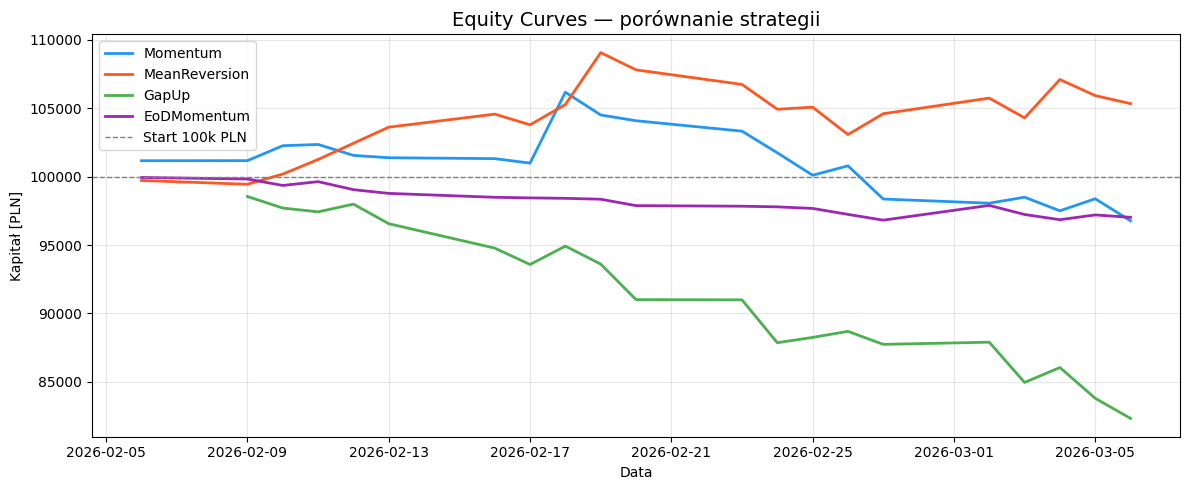

Saved: plot1_equity_curves.png


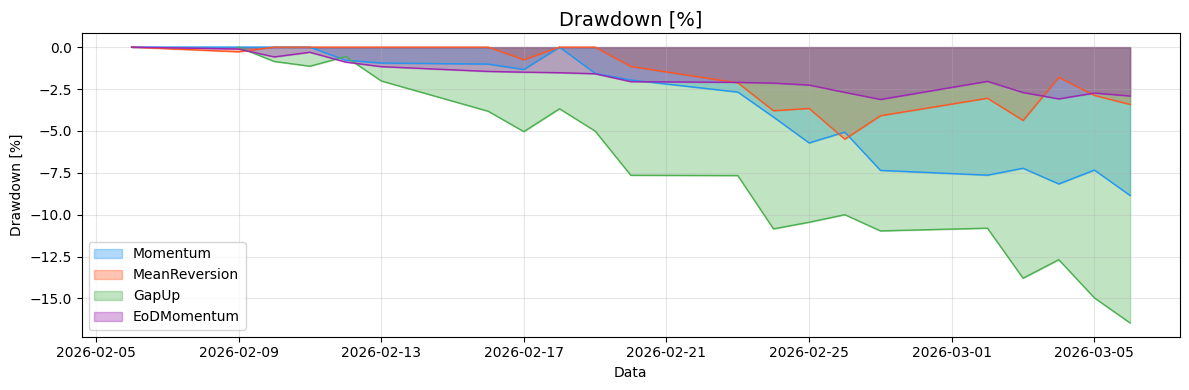

Saved: plot2_drawdown.png


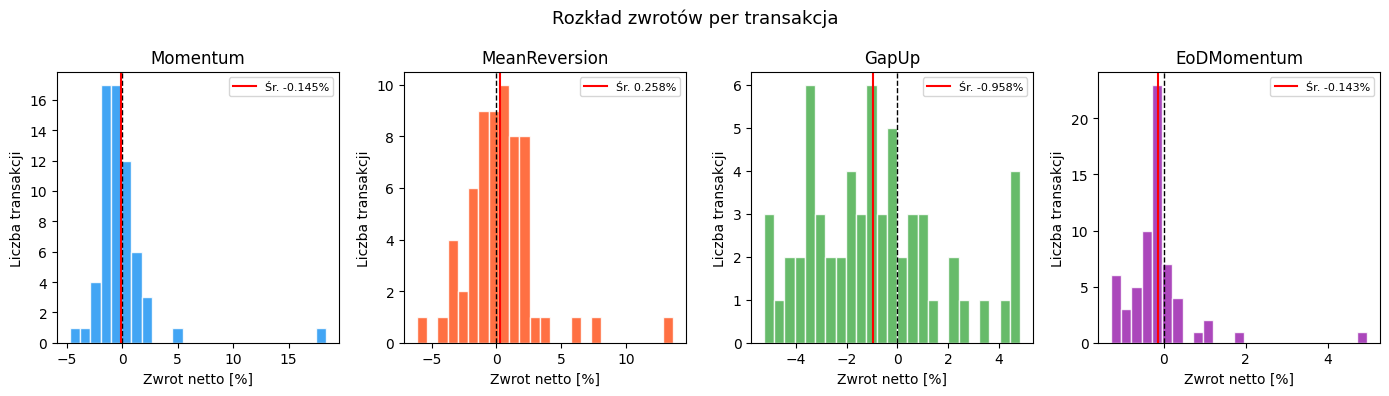

Saved: plot3_return_distributions.png


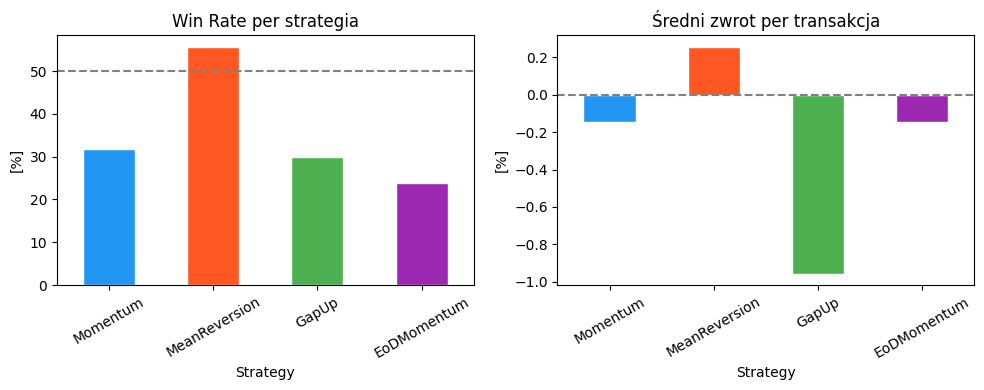

Saved: plot4_win_rate_avg_return.png


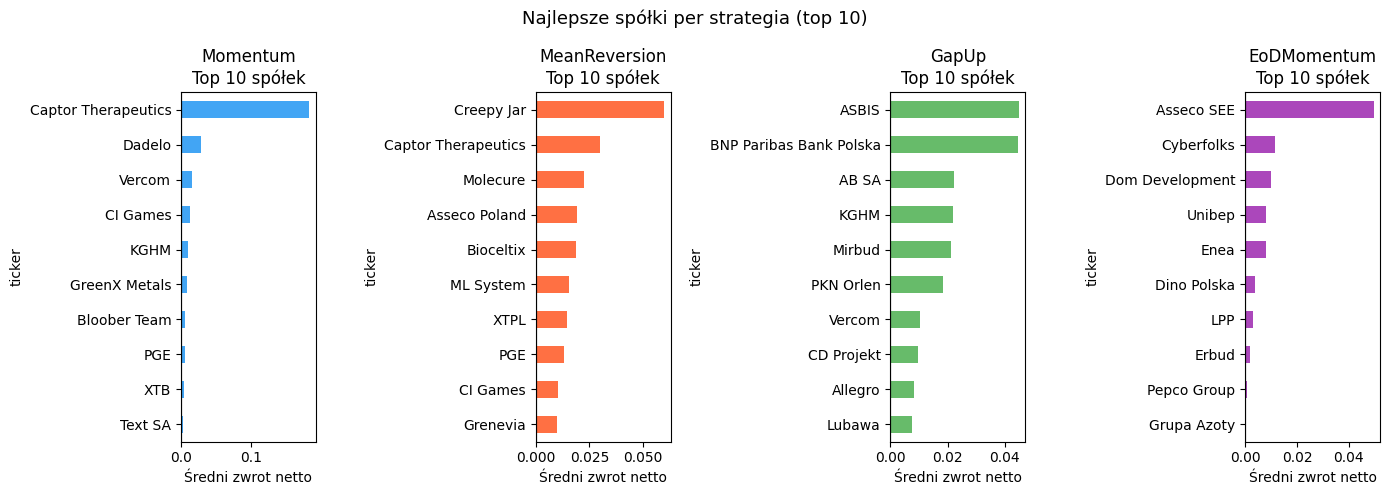

Saved: plot5_top_tickers.png


In [20]:
# ── Visualizations ───────────────────────────────────────────────────────────

def compute_drawdown(equity_series):
    """Returns drawdown series (fraction from running peak)."""
    peak = equity_series.cummax()
    return (equity_series - peak) / peak

def plot_all_results(results):
    """
    results: dict {strategy_name: (trades_df, equity_df)}
    Produces 4 figures:
      1. Equity curves comparison
      2. Drawdown comparison
      3. Return distributions per strategy
      4. Win rate and avg return per strategy
    """
    colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
    names  = list(results.keys())

    # ── Figure 1: Equity curves ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    for (name, (_, eq)), color in zip(results.items(), colors):
        if eq.empty:
            continue
        ax.plot(eq.index, eq['capital'], label=name, color=color, linewidth=2)
    ax.axhline(100_000, color='gray', linestyle='--', linewidth=1, label='Start 100k PLN')
    ax.set_title('Equity Curves — porównanie strategii', fontsize=14)
    ax.set_ylabel('Kapitał [PLN]')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot1_equity_curves.png', dpi=150)
    plt.show()
    print("Saved: plot1_equity_curves.png")

    # ── Figure 2: Drawdown ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    for (name, (_, eq)), color in zip(results.items(), colors):
        if eq.empty:
            continue
        dd = compute_drawdown(eq['capital'])
        ax.fill_between(dd.index, dd.values * 100, 0,
                        alpha=0.35, color=color, label=name)
        ax.plot(dd.index, dd.values * 100, color=color, linewidth=1)
    ax.set_title('Drawdown [%]', fontsize=14)
    ax.set_ylabel('Drawdown [%]')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot2_drawdown.png', dpi=150)
    plt.show()
    print("Saved: plot2_drawdown.png")

    # ── Figure 3: Return distributions ───────────────────────────────────────
    fig, axes = plt.subplots(1, len(results), figsize=(14, 4), sharey=False)
    if len(results) == 1:
        axes = [axes]
    for ax, (name, (tr, _)), color in zip(axes, results.items(), colors):
        if tr.empty:
            ax.set_title(name)
            continue
        ax.hist(tr['net_return'] * 100, bins=25, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        mean_r = tr['net_return'].mean() * 100
        ax.axvline(mean_r, color='red', linestyle='-', linewidth=1.5,
                   label=f'Śr. {mean_r:.3f}%')
        ax.set_title(name)
        ax.set_xlabel('Zwrot netto [%]')
        ax.set_ylabel('Liczba transakcji')
        ax.legend(fontsize=8)
    plt.suptitle('Rozkład zwrotów per transakcja', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot3_return_distributions.png', dpi=150)
    plt.show()
    print("Saved: plot3_return_distributions.png")

    # ── Figure 4: Win rate & avg return ──────────────────────────────────────
    stats = []
    for name, (tr, _) in results.items():
        if tr.empty:
            continue
        wr = (tr['net_return'] > 0).mean() * 100
        avg = tr['net_return'].mean() * 100
        stats.append({'Strategy': name, 'Win Rate [%]': wr, 'Avg Return [%]': avg})
    stats_df = pd.DataFrame(stats).set_index('Strategy')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    stats_df['Win Rate [%]'].plot.bar(ax=axes[0], color=colors[:len(stats_df)],
                                       edgecolor='white')
    axes[0].axhline(50, color='gray', linestyle='--')
    axes[0].set_title('Win Rate per strategia')
    axes[0].set_ylabel('[%]')
    axes[0].tick_params(axis='x', rotation=30)

    stats_df['Avg Return [%]'].plot.bar(ax=axes[1], color=colors[:len(stats_df)],
                                         edgecolor='white')
    axes[1].axhline(0, color='gray', linestyle='--')
    axes[1].set_title('Średni zwrot per transakcja')
    axes[1].set_ylabel('[%]')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('plot4_win_rate_avg_return.png', dpi=150)
    plt.show()
    print("Saved: plot4_win_rate_avg_return.png")

    # ── Figure 5: Top tickers per strategy ───────────────────────────────────
    fig, axes = plt.subplots(1, len(results), figsize=(14, 5))
    if len(results) == 1:
        axes = [axes]
    for ax, (name, (tr, _)), color in zip(axes, results.items(), colors):
        if tr.empty:
            ax.set_title(name)
            continue
        ticker_returns = tr.groupby('ticker')['net_return'].mean().sort_values()
        ticker_returns.tail(10).plot.barh(ax=ax, color=color, alpha=0.85)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{name}\nTop 10 spółek')
        ax.set_xlabel('Średni zwrot netto')
    plt.suptitle('Najlepsze spółki per strategia (top 10)', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot5_top_tickers.png', dpi=150)
    plt.show()
    print("Saved: plot5_top_tickers.png")


# Run all visualizations
all_results = {
    'Momentum':      (trades_mom, equity_mom),
    'MeanReversion': (trades_rev, equity_rev),
    'GapUp':         (trades_gap, equity_gap),
    'EoDMomentum':   (trades_eod, equity_eod),
}

plot_all_results(all_results)


In [23]:
# ── Trade Log — styled DataFrames per strategy ───────────────────────────────

def style_trades(trades_df, strategy_name):
    """
    Returns a styled DataFrame for display in the notebook.
    Highlights positive returns green, negative red.
    """
    if trades_df.empty:
        print(f"{strategy_name}: no trades.")
        return

    df = trades_df.copy()

    # Format columns for display
    df['date']       = df['date'].astype(str)
    df['buy']        = df['buy'].map('{:.2f}'.format)
    df['sell']       = df['sell'].map('{:.2f}'.format)
    df['net_return'] = df['net_return'].map('{:+.4%}'.format)
    df['pnl']        = df['pnl'].map('{:+.2f} PLN'.format)

    # Keep only relevant columns (drop strategy col, redundant)
    cols = ['date', 'ticker', 'buy', 'sell', 'net_return', 'pnl']
    extra = [c for c in ['gap', 'streak'] if c in df.columns]
    display_df = df[cols + extra]

    def color_return(val):
        """Color net_return column: green if positive, red if negative."""
        try:
            v = float(val.replace('%', '').replace('+', ''))
            color = "#004400" if v > 0 else ("#9d0000" if v < 0 else '')
            return f'background-color: {color}'
        except Exception:
            return ''

    def color_pnl(val):
        """Color pnl column: green if positive, red if negative."""
        try:
            v = float(val.replace(' PLN', '').replace('+', ''))
            color = "#002d00" if v > 0 else ("#b30000" if v < 0 else '')
            return f'background-color: {color}'
        except Exception:
            return ''

    styled = (
        display_df.style
        .set_caption(f"📋 Trade Log — {strategy_name} ({len(display_df)} trades)")
        .applymap(color_return, subset=['net_return'])
        .applymap(color_pnl,    subset=['pnl'])
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold'),
                       ('text-align', 'left'), ('padding', '6px 0')]},
            {'selector': 'th',
             'props': [('background-color', '#2c3e50'), ('color', 'white'),
                       ('font-size', '12px'), ('padding', '6px 10px')]},
            {'selector': 'td',
             'props': [('font-size', '12px'), ('padding', '4px 10px'),
                       ('border-bottom', '1px solid #eee')]},
            {'selector': 'tr:hover td',
             'props': [('background-color', '#f0f4ff')]},
        ])
        .hide(axis='index')
    )
    return styled


# Display trade logs for all strategies
from IPython.display import display

for name, (tr, _) in all_results.items():
    display(style_trades(tr, name))
    print()  # spacing between tables


C:\Users\szymo\AppData\Local\Temp\ipykernel_20092\323563276.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_return, subset=['net_return'])
C:\Users\szymo\AppData\Local\Temp\ipykernel_20092\323563276.py:48: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pnl,    subset=['pnl'])


date,ticker,buy,sell,net_return,pnl
2026-02-06,Dadelo,77.80,78.60,+0.9283%,+309.42 PLN
2026-02-06,Bumech,18.30,18.62,+1.6486%,+549.55 PLN
2026-02-06,GreenX Metals,2.38,2.40,+0.9101%,+303.37 PLN
2026-02-09,Bumech,20.90,20.75,-0.8177%,-275.74 PLN
2026-02-09,CI Games,2.30,2.31,+0.1174%,+39.59 PLN
2026-02-09,XTB,90.36,91.10,+0.7189%,+242.43 PLN
2026-02-10,Bumech,24.65,24.65,-0.1000%,-33.72 PLN
2026-02-10,CI Games,2.47,2.54,+2.5263%,+851.93 PLN
2026-02-10,Bank Ochrony Srodowiska,11.00,11.10,+0.8091%,+272.85 PLN
2026-02-11,JSW,25.50,25.47,-0.2176%,-74.19 PLN


C:\Users\szymo\AppData\Local\Temp\ipykernel_20092\323563276.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_return, subset=['net_return'])
C:\Users\szymo\AppData\Local\Temp\ipykernel_20092\323563276.py:48: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pnl,    subset=['pnl'])


date,ticker,buy,sell,net_return,pnl
2026-02-06,ML System,17.42,17.58,+0.8185%,+272.83 PLN
2026-02-06,Selena FM,55.80,55.80,-0.1000%,-33.33 PLN
2026-02-06,Vercom,137.00,135.00,-1.5599%,-519.95 PLN
2026-02-09,Unimot,128.40,129.60,+0.8346%,+277.42 PLN
2026-02-09,Bank Millennium,17.74,17.68,-0.4382%,-145.66 PLN
2026-02-09,Polenergia,53.00,52.40,-1.2321%,-409.54 PLN
2026-02-10,XTPL,65.00,65.50,+0.6692%,+221.83 PLN
2026-02-10,CD Projekt,245.70,247.40,+0.5919%,+196.20 PLN
2026-02-10,Grenevia,13.75,13.90,+0.9909%,+328.46 PLN
2026-02-11,Asseco Poland,184.70,188.40,+1.9032%,+635.61 PLN


C:\Users\szymo\AppData\Local\Temp\ipykernel_20092\323563276.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_return, subset=['net_return'])
C:\Users\szymo\AppData\Local\Temp\ipykernel_20092\323563276.py:48: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pnl,    subset=['pnl'])


date,ticker,buy,sell,net_return,pnl,gap
2026-02-09,Dadelo,78.80,76.20,-3.3995%,-1133.17 PLN,0.026042
2026-02-09,CD Projekt,246.20,248.80,+0.9561%,+318.68 PLN,0.025833
2026-02-09,Unimot,132.00,129.60,-1.9182%,-639.39 PLN,0.023256
2026-02-10,Polenergia,54.00,53.80,-0.4704%,-154.51 PLN,0.030534
2026-02-10,Cyberfolks,204.00,197.80,-3.1392%,-1031.19 PLN,0.027190
2026-02-10,Vercom,139.40,141.00,+1.0478%,+344.18 PLN,0.023495
2026-02-11,Asseco Poland,198.60,188.40,-5.2360%,-1705.26 PLN,0.032761
2026-02-11,BNP Paribas Bank Polska,153.00,160.00,+4.4752%,+1457.48 PLN,0.026846
2026-02-11,Creepy Jar,608.00,608.00,-0.1000%,-32.57 PLN,0.020134
2026-02-12,Erbud,31.30,32.85,+4.8521%,+1575.70 PLN,0.021207


C:\Users\szymo\AppData\Local\Temp\ipykernel_20092\323563276.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_return, subset=['net_return'])
C:\Users\szymo\AppData\Local\Temp\ipykernel_20092\323563276.py:48: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pnl,    subset=['pnl'])


date,ticker,buy,sell,net_return,pnl,streak
2026-02-06,Grupa Azoty,17.30,17.32,+0.0156%,+5.20 PLN,5
2026-02-06,Bank Ochrony Srodowiska,10.54,10.54,-0.1000%,-33.33 PLN,4
2026-02-06,Creepy Jar,614.00,614.00,-0.1000%,-33.33 PLN,4
2026-02-09,KGHM,321.00,321.20,-0.0377%,-12.56 PLN,5
2026-02-09,Develia,9.91,9.90,-0.2009%,-66.93 PLN,5
2026-02-09,ML System,18.56,18.56,-0.1000%,-33.31 PLN,5
2026-02-10,Rainbow Tours,163.10,163.10,-0.1000%,-33.28 PLN,4
2026-02-10,Selvita,45.00,44.50,-1.2111%,-403.00 PLN,4
2026-02-10,Unibep,15.95,15.95,-0.1000%,-33.28 PLN,3
2026-02-11,Creepy Jar,608.00,608.00,-0.1000%,-33.12 PLN,4


In [22]:
# ── Detailed Print Summary ───────────────────────────────────────────────────
print("=" * 65)
print("  INTRADAY STRATEGIES — WIG80 — PODSUMOWANIE")
print("=" * 65)

from datetime import date as dt_date

for strat_name, (tr, eq) in all_results.items():
    print(f"\n{'─'*65}")
    print(f"  Strategia: {strat_name}")
    print(f"{'─'*65}")

    if tr.empty or eq.empty:
        print("  Brak transakcji.")
        continue

    initial = 100_000
    final   = eq['capital'].iloc[-1]
    total_ret = (final - initial) / initial * 100

    n_trades   = len(tr)
    n_days     = len(eq)
    win_rate   = (tr['net_return'] > 0).mean() * 100
    avg_ret    = tr['net_return'].mean() * 100
    median_ret = tr['net_return'].median() * 100
    best_trade = tr['net_return'].max() * 100
    worst_trade= tr['net_return'].min() * 100
    total_pnl  = tr['pnl'].sum()

    # Drawdown
    peak = eq['capital'].cummax()
    dd   = ((eq['capital'] - peak) / peak * 100)
    max_dd = dd.min()

    # Sharpe (simplified: daily PnL / std)
    daily_pnl = tr.groupby('date')['pnl'].sum()
    sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0

    print(f"  Kapitał startowy :  {initial:>12,.0f} PLN")
    print(f"  Kapitał końcowy  :  {final:>12,.0f} PLN")
    print(f"  Zwrot całkowity  :  {total_ret:>11.2f} %")
    print(f"  Max Drawdown     :  {max_dd:>11.2f} %")
    print(f"  Sharpe (annul.)  :  {sharpe:>11.2f}")
    print(f"  Liczba transakcji:  {n_trades:>12}")
    print(f"  Liczba dni sesji :  {n_days:>12}")
    print(f"  Win Rate         :  {win_rate:>11.1f} %")
    print(f"  Śr. zwrot/trans. :  {avg_ret:>11.4f} %")
    print(f"  Mediana zwrotu   :  {median_ret:>11.4f} %")
    print(f"  Najlepsza trans. :  {best_trade:>11.4f} %")
    print(f"  Najgorsza trans. :  {worst_trade:>11.4f} %")
    print(f"  Łączny PnL       :  {total_pnl:>12,.2f} PLN")

    # Top 5 tickers by mean return
    top5 = tr.groupby('ticker')['net_return'].mean().sort_values(ascending=False).head(5)
    print(f"\n  Top 5 spółek (śr. zwrot):")
    for ticker, ret in top5.items():
        print(f"    {ticker:<25} {ret*100:+.4f}%")

print("\n" + "=" * 65)
print("  Wykresy zapisane:")
for i, fname in enumerate(['plot1_equity_curves.png', 'plot2_drawdown.png',
                            'plot3_return_distributions.png',
                            'plot4_win_rate_avg_return.png',
                            'plot5_top_tickers.png'], 1):
    print(f"    [{i}] {fname}")
print("=" * 65)


  INTRADAY STRATEGIES — WIG80 — PODSUMOWANIE

─────────────────────────────────────────────────────────────────
  Strategia: Momentum
─────────────────────────────────────────────────────────────────
  Kapitał startowy :       100,000 PLN
  Kapitał końcowy  :        96,772 PLN
  Zwrot całkowity  :        -3.23 %
  Max Drawdown     :        -8.85 %
  Sharpe (annul.)  :        -1.55
  Liczba transakcji:            63
  Liczba dni sesji :            21
  Win Rate         :         31.7 %
  Śr. zwrot/trans. :      -0.1448 %
  Mediana zwrotu   :      -0.4021 %
  Najlepsza trans. :      18.3797 %
  Najgorsza trans. :      -4.7296 %
  Łączny PnL       :     -3,227.56 PLN

  Top 5 spółek (śr. zwrot):
    Captor Therapeutics       +18.3797%
    Dadelo                    +2.8153%
    Vercom                    +1.6350%
    CI Games                  +1.3218%
    KGHM                      +0.9432%

─────────────────────────────────────────────────────────────────
  Strategia: MeanReversion
────────